<a href="https://colab.research.google.com/github/neha26-jpg/chatbot-/blob/main/studenthabit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#install kaggle
!pip install kaggle--quiet

ERROR: Could not find a version that satisfies the requirement kaggle--quiet (from versions: none)
ERROR: No matching distribution found for kaggle--quiet


In [3]:
#upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nehakumari26","key":"776c066bbb39facb4cb2c97fb2325c2b"}'}

In [5]:
#create kaggle directory
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [9]:
#copy kaggle.json file
!cp kaggle.json ~/.kaggle/

In [11]:
ls-ltr ~/.kaggle

total 4
-rw-r--r-- 1 root root 68 Sep 21 04:45 kaggle.json


In [14]:
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
#list down all competition
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [17]:
#list down all datasets
!kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
datascikhan/e-commerce-sales-and-customer-analytics             E-Commerce Sales Analytics Dataset                    29815424  2026-08-25 08:00:46.013000          10041        214                1  
srisyra02/online-food-ordering-dataset                          Online Food Ordering Dataset                              3648  2026-08-23 15:26:25.483000           7063        113                1  
harishyadav0506/impact-of-social-media-on-life                  Impact of Social Media on Life                           78980  2026-09-09 18:10:54.497000            974         25                1  


In [18]:
!kaggle datasets list -s 'student_habits_performance.csv'

ref                                                          title                                          size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ---------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nasasiratomowen/student-habits-performance-csv               student_habits_performance.csv                19512  2025-05-23 06:01:22.727000            361          0  0.23529412       
rajveers222/sutudenthabit                                    sutudenthabit                                 19512  2025-06-12 08:57:19.710000              6         10  0.23529412       
ashmkaur/students-performance                                students_performance                          19512  2025-06-12 08:48:28.700000             27          9  0.23529412       
zeeshanahmadyar/student-score-and-hibits                     Student S

In [21]:
!kaggle datasets download -d 'nasasiratomowen/student-habits-performance-csv' -p ../data/kaggleDatasetforStudentHabits

Dataset URL: https://www.kaggle.com/datasets/nasasiratomowen/student-habits-performance-csv
License(s): CC0-1.0
100% 19.1k/19.1k [00:00<00:00, 36.9MB/s]



In [24]:
ls -ltr ..import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("student_habits.csv")

# Display data
print(df.head())
print(df.info())

# Check missing values
print(df.isnull().sum())

# Select features and target
features = [
    "study_hours",
    "sleep_hours",
    "attendance",
    "exercise_hours",
    "social_media_hours"
]

X = df[features]
y = df["final_score"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot feature importance
importance.plot(kind="bar", color="skyblue")
plt.title("Factors Affecting Student Performance")
plt.xlabel("Student Habit")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (246167007.py, line 1)

In [23]:
!unzip ../data/kaggleDatasetforStudentHabits/student-habits-performance-csv.zip -d ../data/kaggleDatasetforStudentHabits

Archive:  ../data/kaggleDatasetforStudentHabits/student-habits-performance-csv.zip
  inflating: ../data/kaggleDatasetforStudentHabits/student_habits_performance.csv  


  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                   Master          Average  

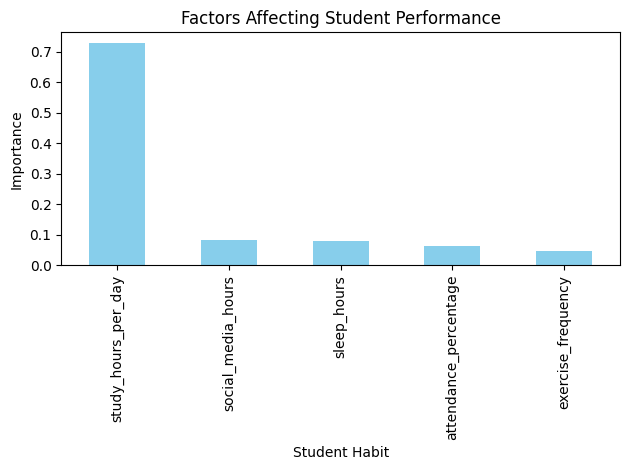

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("../data/kaggleDatasetforStudentHabits/student_habits_performance.csv")

# Display data
print(df.head())
print(df.info())

# Check missing values
print(df.isnull().sum())

# Select features and target
features = [
    "study_hours_per_day",
    "sleep_hours",
    "attendance_percentage",
    "exercise_frequency",
    "social_media_hours"
]

X = df[features]
y = df["exam_score"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot feature importance
importance.plot(kind="bar", color="skyblue")
plt.title("Factors Affecting Student Performance")
plt.xlabel("Student Habit")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()